In [ ]:
## Extract data

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.neighbors import NearestNeighbors

df = pd.read_csv(r"../../../data/raw/real-estate.csv")
features = ["Prix","Surface","Nb_Pieces"]
X = df[features].copy()
X_scaled = StandardScaler().fit_transform(X)
X_pca = PCA(n_components=2, random_state=42).fit_transform(X_scaled)

In [10]:
def evaluate_clustering(X, labels, method_name="Méthode"):
    labels = np.array(labels)
    unique_labels = set(labels)
    n_clusters = len(unique_labels - {-1}) if -1 in unique_labels else len(unique_labels)
    noise_ratio = np.mean(labels == -1) if -1 in unique_labels else 0.0

    result = {"Méthode": method_name, "Nb_clusters": n_clusters, "Silhouette": np.nan, "Davies_Bouldin": np.nan, "Noise_ratio": noise_ratio}
    mask = labels != -1
    filtered_X = X[mask]
    filtered_labels = labels[mask]
    if len(set(filtered_labels)) >= 2 and len(filtered_X) > len(set(filtered_labels)):
        result["Silhouette"] = silhouette_score(filtered_X, filtered_labels)
        result["Davies_Bouldin"] = davies_bouldin_score(filtered_X, filtered_labels)
    return result

In [11]:
## K-means automatique

In [21]:
best_k = None
best_score = -1
for k in range(2, 5):
    km = KMeans(n_clusters=k, init="k-means++", n_init=20, random_state=42)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    if score > best_score:
        best_score = score
        best_k = k
        kmeans_labels = labels
print("Meilleur K :", best_k)
kmeans_eval = evaluate_clustering(X_scaled, kmeans_labels, "KMeans_auto")

Meilleur K : 4


In [13]:
## DBSCAN automatique

In [22]:
best_combined = -np.inf
dbscan_labels = None
for eps in np.round(np.arange(0.30, 1.81, 0.10), 2):
    for min_samples in range(3, 9):
        db = DBSCAN(eps=float(eps), min_samples=int(min_samples))
        labels = db.fit_predict(X_scaled)
        mask = np.array(labels) != -1
        filtered_X = X_scaled[mask]
        filtered_labels = np.array(labels)[mask]
        clusters = len(set(filtered_labels))
        if clusters < 2 or len(filtered_X) <= clusters:
            continue
        sil = silhouette_score(filtered_X, filtered_labels)
        dbi = davies_bouldin_score(filtered_X, filtered_labels)
        noise = np.mean(np.array(labels) == -1)
        combined = sil - 0.15 * noise - 0.05 * dbi
        if combined > best_combined:
            best_combined = combined
            dbscan_labels = labels
dbscan_eval = evaluate_clustering(X_scaled, dbscan_labels, "DBSCAN_auto")

In [23]:
## CAH

In [24]:
Z = linkage(X_scaled, method="ward")
cah_labels = fcluster(Z, t=best_k, criterion="maxclust")
cah_eval = evaluate_clustering(X_scaled, cah_labels, "CAH")

In [25]:
## Tableau final

In [26]:
comparison = pd.DataFrame([kmeans_eval, dbscan_eval, cah_eval])
comparison["Selection_score"] = (
    comparison["Silhouette"].fillna(-1)
    - 0.05 * comparison["Davies_Bouldin"].fillna(0)
    - 0.10 * comparison["Noise_ratio"].fillna(0)
)
comparison = comparison.sort_values("Selection_score", ascending=False).reset_index(drop=True)
display(comparison)
print("Meilleure méthode :", comparison.loc[0, "Méthode"])

,Méthode,Nb_clusters,Silhouette,Davies_Bouldin,Noise_ratio,Selection_score
0,DBSCAN_auto,4,0.717160,0.334467,0.74,0.626437
1,KMeans_auto,4,0.340365,1.000388,0.00,0.290346
2,CAH,4,0.314969,0.961220,0.00,0.266908


Meilleure méthode : DBSCAN_auto


In [27]:
## Visualisation comparative

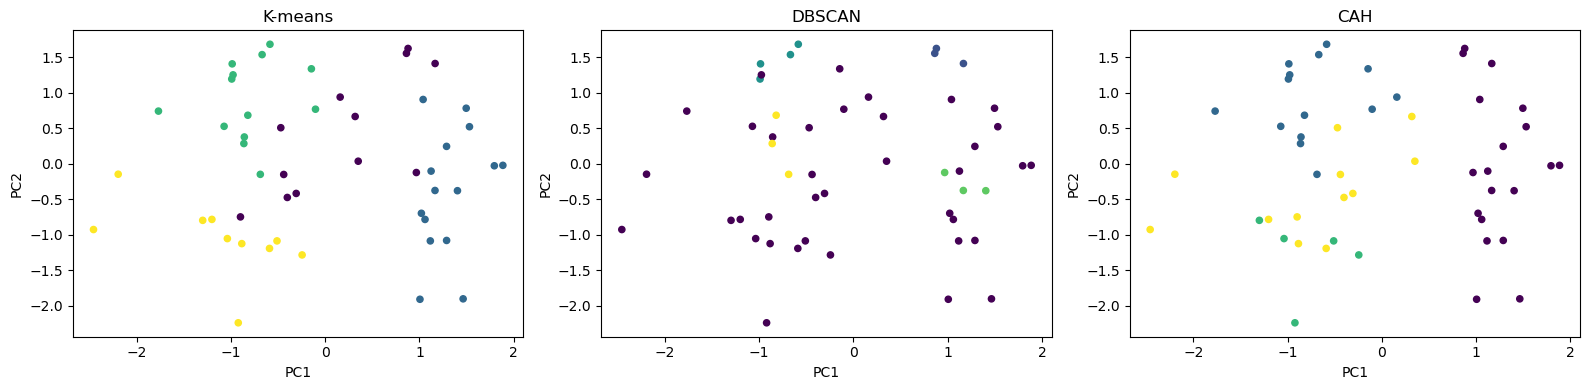

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].scatter(X_pca[:,0], X_pca[:,1], c=kmeans_labels, s=20)
axes[0].set_title("K-means")
axes[1].scatter(X_pca[:,0], X_pca[:,1], c=dbscan_labels, s=20)
axes[1].set_title("DBSCAN")
axes[2].scatter(X_pca[:,0], X_pca[:,1], c=cah_labels, s=20)
axes[2].set_title("CAH")
for ax in axes:
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
plt.tight_layout()
plt.show()